## 1. Install Dependencies

In [1]:
!pip install -q spacy

!pip install -q spacy-transformers

!python -m spacy download en_core_web_trf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 984.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 1.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by sel

## 2. Import Libraries

In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

tqdm.pandas()

## 3. paths

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/FinSight_AI"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data"
)

PROCESSED_PATH = os.path.join(
    DATA_PATH,
    "processed"
)

INTERIM_DATA = os.path.join(
    DATA_PATH,
    "interim"
)

REPORT_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)

## 4. Load Dataset

In [4]:
news_df = pd.read_parquet(

    os.path.join(
        PROCESSED_PATH,
        "financial_news_clean.parquet"
    )

)

In [5]:
print(news_df.shape)

news_df.head()

(3215296, 18)


,news_id,headline,url,publisher,published_date,ticker,source,year,month,day,weekday,hour,headline_length,word_count,has_time,original_headline,clean_character_count,clean_word_count
0,1,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,analyst,2020,6,5,Friday,14,39,7,True,Stocks That Hit 52-Week Highs On Friday,39,7
1,2,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,analyst,2020,6,3,Wednesday,14,42,7,True,Stocks That Hit 52-Week Highs On Wednesday,42,7
2,3,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,analyst,2020,5,26,Tuesday,8,29,5,True,71 Biggest Movers From Friday,29,5
3,4,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,analyst,2020,5,22,Friday,16,44,7,True,46 Stocks Moving In Friday's Mid-Day Session,44,7
4,5,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,analyst,2020,5,22,Friday,15,87,14,True,B of A Securities Maintains Neutral on Agilent...,87,14


## 5. Load Transformer Model

In [6]:
nlp = spacy.load(
    "en_core_web_trf"
)

In [7]:
nlp.pipe_names

['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

## 6. Configure Batch Size

In [8]:
BATCH_SIZE = 512

## 7. Disable Unnecessary Components

In [9]:
nlp.disable_pipes(

    "tagger",

    "parser",

    "lemmatizer",

    "attribute_ruler"

)

['tagger', 'parser', 'lemmatizer', 'attribute_ruler']

In [10]:
print(nlp.pipe_names)

['transformer', 'ner']


## 8. Quick Test

In [11]:
sample = news_df.loc[0, "headline"]

sample

'Stocks That Hit 52-Week Highs On Friday'

In [12]:
doc = nlp(sample)

for ent in doc.ents:

    print(

        ent.text,

        "---->",

        ent.label_

    )

52-Week ----> DATE
Friday ----> DATE


## 8. Test Multiple Headlines

In [13]:
samples = news_df["headline"].head(10)

In [14]:
for doc in nlp.pipe(

    samples,

    batch_size=8

):

    print("-" * 60)

    print(doc.text)

    print()

    for ent in doc.ents:

        print(

            ent.text,

            ent.label_

        )

------------------------------------------------------------
Stocks That Hit 52-Week Highs On Friday

52-Week DATE
Friday DATE
------------------------------------------------------------
Stocks That Hit 52-Week Highs On Wednesday

52-Week DATE
Wednesday DATE
------------------------------------------------------------
71 Biggest Movers From Friday

71 CARDINAL
Friday DATE
------------------------------------------------------------
46 Stocks Moving In Friday's Mid-Day Session

46 CARDINAL
Friday DATE
Mid-Day TIME
------------------------------------------------------------
B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88

B of A Securities ORG
Agilent Technologies ORG
88 MONEY
------------------------------------------------------------
CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85

CFRA ORG
Agilent Technologies ORG
85 MONEY
------------------------------------------------------------
UBS Maintains Neutral on Agilent Tec

## 9. Add EntityRuler

In [15]:
from spacy.pipeline import EntityRuler

### Create EntityRuler

In [16]:
ruler = nlp.add_pipe(
    "entity_ruler",
    before="ner",
    config={
        "phrase_matcher_attr": "LOWER"
    }
)

## 10. Create Financial Patterns

In [17]:
patterns = [

# Financial Metrics
{"label":"FIN_METRIC","pattern":"EPS"},
{"label":"FIN_METRIC","pattern":"Revenue"},
{"label":"FIN_METRIC","pattern":"EBITDA"},
{"label":"FIN_METRIC","pattern":"Net Income"},
{"label":"FIN_METRIC","pattern":"Operating Income"},
{"label":"FIN_METRIC","pattern":"Cash Flow"},
{"label":"FIN_METRIC","pattern":"Gross Margin"},
{"label":"FIN_METRIC","pattern":"Profit Margin"},
{"label":"FIN_METRIC","pattern":"Free Cash Flow"},

# Financial Periods
{"label":"FIN_PERIOD","pattern":"Q1"},
{"label":"FIN_PERIOD","pattern":"Q2"},
{"label":"FIN_PERIOD","pattern":"Q3"},
{"label":"FIN_PERIOD","pattern":"Q4"},
{"label":"FIN_PERIOD","pattern":"FY2020"},
{"label":"FIN_PERIOD","pattern":"FY2021"},
{"label":"FIN_PERIOD","pattern":"FY2022"},
{"label":"FIN_PERIOD","pattern":"FY2023"},
{"label":"FIN_PERIOD","pattern":"FY2024"},
{"label":"FIN_PERIOD","pattern":"Fiscal Year"},

# Analyst Terms
{"label":"ANALYST_TERM","pattern":"Price Target"},
{"label":"ANALYST_TERM","pattern":"Target Price"},
{"label":"ANALYST_TERM","pattern":"Consensus Estimate"},
{"label":"ANALYST_TERM","pattern":"Consensus"},
{"label":"ANALYST_TERM","pattern":"PT"},

# Analyst Actions
{"label":"ANALYST_ACTION","pattern":"Upgrade"},
{"label":"ANALYST_ACTION","pattern":"Downgrade"},
{"label":"ANALYST_ACTION","pattern":"Maintains"},
{"label":"ANALYST_ACTION","pattern":"Initiates"},
{"label":"ANALYST_ACTION","pattern":"Reiterates"},
{"label":"ANALYST_ACTION","pattern":"Raises"},
{"label":"ANALYST_ACTION","pattern":"Lowers"},

# Analyst Ratings
{"label":"ANALYST_RATING","pattern":"Strong Buy"},
{"label":"ANALYST_RATING","pattern":"Buy"},
{"label":"ANALYST_RATING","pattern":"Hold"},
{"label":"ANALYST_RATING","pattern":"Neutral"},
{"label":"ANALYST_RATING","pattern":"Sell"},
{"label":"ANALYST_RATING","pattern":"Strong Sell"},
{"label":"ANALYST_RATING","pattern":"Outperform"},
{"label":"ANALYST_RATING","pattern":"Underperform"},
{"label":"ANALYST_RATING","pattern":"Overweight"},
{"label":"ANALYST_RATING","pattern":"Underweight"},

# Corporate Actions
{"label":"CORPORATE_ACTION","pattern":"Dividend"},
{"label":"CORPORATE_ACTION","pattern":"Buyback"},
{"label":"CORPORATE_ACTION","pattern":"Share Repurchase"},
{"label":"CORPORATE_ACTION","pattern":"Stock Split"},

# Corporate Events
{"label":"CORPORATE_EVENT","pattern":"IPO"},
{"label":"CORPORATE_EVENT","pattern":"Acquisition"},
{"label":"CORPORATE_EVENT","pattern":"Merger"},
{"label":"CORPORATE_EVENT","pattern":"Bankruptcy"},
{"label":"CORPORATE_EVENT","pattern":"Delisting"},
{"label":"CORPORATE_EVENT","pattern":"Spinoff"},

# Market Events
{"label":"MARKET_EVENT","pattern":"Rally"},
{"label":"MARKET_EVENT","pattern":"Selloff"},
{"label":"MARKET_EVENT","pattern":"Correction"},
{"label":"MARKET_EVENT","pattern":"Crash"},
{"label":"MARKET_EVENT","pattern":"Rebound"},

# Security Types
{"label":"SECURITY_TYPE","pattern":"ETF"},
{"label":"SECURITY_TYPE","pattern":"ADR"},
{"label":"SECURITY_TYPE","pattern":"Bond"},
{"label":"SECURITY_TYPE","pattern":"Bonds"},
{"label":"SECURITY_TYPE","pattern":"Future"},
{"label":"SECURITY_TYPE","pattern":"Futures"},
{"label":"SECURITY_TYPE","pattern":"Option"},
{"label":"SECURITY_TYPE","pattern":"Options"}

]

### Executive Roles

In [18]:
executive_patterns = [

    {"label":"EXECUTIVE_ROLE","pattern":"CEO"},
    {"label":"EXECUTIVE_ROLE","pattern":"CFO"},
    {"label":"EXECUTIVE_ROLE","pattern":"COO"},
    {"label":"EXECUTIVE_ROLE","pattern":"CTO"},
    {"label":"EXECUTIVE_ROLE","pattern":"CIO"},
    {"label":"EXECUTIVE_ROLE","pattern":"CMO"},
    {"label":"EXECUTIVE_ROLE","pattern":"Chairman"},
    {"label":"EXECUTIVE_ROLE","pattern":"President"},
    {"label":"EXECUTIVE_ROLE","pattern":"Founder"},
    {"label":"EXECUTIVE_ROLE","pattern":"Co-Founder"},
    {"label":"EXECUTIVE_ROLE","pattern":"Vice President"},
    {"label":"EXECUTIVE_ROLE","pattern":"Managing Director"},
    {"label":"EXECUTIVE_ROLE","pattern":"Director"}

]

In [19]:
patterns.extend(executive_patterns)

print(f"Total Patterns : {len(patterns)}")

Total Patterns : 77


### Financial Organizations

In [20]:
institution_patterns = [

    {"label":"FINANCIAL_INSTITUTION","pattern":"Federal Reserve"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"Fed"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"SEC"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"NYSE"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"NASDAQ"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"ECB"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"IMF"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"World Bank"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"FDA"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"FINRA"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"FOMC"},
    {"label":"FINANCIAL_INSTITUTION","pattern":"Treasury"}

]

In [21]:
patterns.extend(institution_patterns)

print(f"Total Patterns : {len(patterns)}")

Total Patterns : 89


### Currency & Crypto

In [22]:
currency_patterns = [

    {"label":"CURRENCY","pattern":"USD"},
    {"label":"CURRENCY","pattern":"EUR"},
    {"label":"CURRENCY","pattern":"GBP"},
    {"label":"CURRENCY","pattern":"JPY"},
    {"label":"CURRENCY","pattern":"INR"},
    {"label":"CURRENCY","pattern":"CNY"},
    {"label":"CURRENCY","pattern":"BTC"},
    {"label":"CURRENCY","pattern":"Bitcoin"},
    {"label":"CURRENCY","pattern":"ETH"},
    {"label":"CURRENCY","pattern":"Ethereum"}

]

In [23]:
patterns.extend(currency_patterns)

print(f"Total Patterns : {len(patterns)}")

Total Patterns : 99


### Load Patterns

In [24]:
ruler.add_patterns(patterns)

print(f"Financial Patterns Added : {len(patterns)}")

Financial Patterns Added : 99


## 11. Test Again

In [25]:
test_headlines = [

    "Apple CEO Tim Cook announced a new Buyback Program.",

    "The Federal Reserve raised interest rates.",

    "Microsoft CFO discussed Revenue and EPS guidance.",

    "Bitcoin ETF approved by SEC.",

    "NASDAQ rallied after strong earnings."

]

for text in test_headlines:

    print("-"*80)

    print(text)

    print()

    doc = nlp(text)

    for ent in doc.ents:

        print(f"{ent.text:<30} {ent.label_}")

    print()

--------------------------------------------------------------------------------
Apple CEO Tim Cook announced a new Buyback Program.

Apple                          ORG
CEO                            EXECUTIVE_ROLE
Tim Cook                       PERSON
Buyback                        CORPORATE_ACTION

--------------------------------------------------------------------------------
The Federal Reserve raised interest rates.

Federal Reserve                FINANCIAL_INSTITUTION

--------------------------------------------------------------------------------
Microsoft CFO discussed Revenue and EPS guidance.

Microsoft                      ORG
CFO                            EXECUTIVE_ROLE
Revenue                        FIN_METRIC
EPS                            FIN_METRIC

--------------------------------------------------------------------------------
Bitcoin ETF approved by SEC.

Bitcoin                        CURRENCY
ETF                            SECURITY_TYPE
SEC                      

## 12. Test on 100 Random Headlines



In [26]:
# Select 100 random headlines
sample_df = news_df.sample(
    n=100,
    random_state=42
).reset_index(drop=True)

sample_df.head()

,news_id,headline,url,publisher,published_date,ticker,source,year,month,day,weekday,hour,headline_length,word_count,has_time,original_headline,clean_character_count,clean_word_count
0,66764,Antero Midstream shares are trading lower afte...,https://www.benzinga.com/markets/wiim/19/11/14...,Benzinga Newsdesk,2019-11-07 00:00:00+00:00,AM,analyst,2019,11,7,Thursday,0,242,39,True,Antero Midstream shares are trading lower afte...,242,39
1,1666858,Cnooc's Nexen cutting 340 jobs in North Americ...,http://seekingalpha.com/news/2374556-cnoocs-ne...,Seeking Alpha,2015-03-17 00:00:00+00:00,CEO,partner,2015,3,17,Tuesday,0,73,13,False,Cnooc's Nexen cutting 340 jobs in North Americ...,73,13
2,2344335,Valuation Dashboard: Energy And Materials - Up...,http://seekingalpha.com/article/3770806-valuat...,Seeking Alpha,2015-12-22 00:00:00+00:00,KS,partner,2015,12,22,Tuesday,0,50,7,False,Valuation Dashboard: Energy And Materials - Up...,50,7
3,2050800,China Faces Tough Decisions Ahead,http://seekingalpha.com/article/4031525-china-...,Seeking Alpha,2016-12-19 00:00:00+00:00,FXP,partner,2016,12,19,Monday,0,33,5,False,China Faces Tough Decisions Ahead,33,5
4,1549634,Dividend Challenger Highlights: Week Of May 26,https://seekingalpha.com/article/4266482-divid...,Seeking Alpha,2019-05-25 00:00:00+00:00,AYR,partner,2019,5,25,Saturday,0,46,7,False,Dividend Challenger Highlights: Week Of May 26,46,7


### Entity Normalization

In [27]:
ENTITY_NORMALIZATION = {

    "pt":"PRICE_TARGET",

    "price target":"PRICE_TARGET",

    "target price":"PRICE_TARGET",

    "price objective":"PRICE_TARGET",

    "buyback":"BUYBACK",

    "share buyback":"BUYBACK",

    "share repurchase":"BUYBACK",

    "repurchase program":"BUYBACK",

    "eps":"EARNINGS_PER_SHARE",

    "revenue":"REVENUE",

    "sales":"REVENUE",

    "net income":"NET_INCOME",

    "cash flow":"CASH_FLOW",

    "free cash flow":"FREE_CASH_FLOW",

    "q1":"QUARTER_1",

    "q2":"QUARTER_2",

    "q3":"QUARTER_3",

    "q4":"QUARTER_4"

}

In [28]:
def normalize_entity(text):

    key = text.strip().lower()

    return ENTITY_NORMALIZATION.get(key, text)

In [29]:
examples = [

    "PT",
    "Price Target",
    "Target Price",
    "Buyback",
    "Share Repurchase",
    "EPS",
    "Revenue",
    "Q2"

]

for item in examples:

    print(f"{item:<20} ---> {normalize_entity(item)}")

PT                   ---> PRICE_TARGET
Price Target         ---> PRICE_TARGET
Target Price         ---> PRICE_TARGET
Buyback              ---> BUYBACK
Share Repurchase     ---> BUYBACK
EPS                  ---> EARNINGS_PER_SHARE
Revenue              ---> REVENUE
Q2                   ---> QUARTER_2


## 13. Extract Entities from Sample

In [30]:
def extract_entities(doc):
    """
    Extract entities in a structured format.
    """

    entities = []

    for ent in doc.ents:

        entities.append({

            "entity": ent.text,

            "normalized_entity": normalize_entity(ent.text),

            "label": ent.label_,

            "start": ent.start_char,

            "end": ent.end_char,

            "length": len(ent.text)

        })

    return entities

In [31]:
doc = nlp(

    "UBS Raises Price Target to $87 after strong Q2 EPS."

)

extract_entities(doc)

[{'entity': 'UBS',
  'normalized_entity': 'UBS',
  'label': 'ORG',
  'start': 0,
  'end': 3,
  'length': 3},
 {'entity': 'Raises',
  'normalized_entity': 'Raises',
  'label': 'ANALYST_ACTION',
  'start': 4,
  'end': 10,
  'length': 6},
 {'entity': 'Price Target',
  'normalized_entity': 'PRICE_TARGET',
  'label': 'ANALYST_TERM',
  'start': 11,
  'end': 23,
  'length': 12},
 {'entity': '87',
  'normalized_entity': '87',
  'label': 'MONEY',
  'start': 28,
  'end': 30,
  'length': 2},
 {'entity': 'Q2',
  'normalized_entity': 'QUARTER_2',
  'label': 'FIN_PERIOD',
  'start': 44,
  'end': 46,
  'length': 2},
 {'entity': 'EPS',
  'normalized_entity': 'EARNINGS_PER_SHARE',
  'label': 'FIN_METRIC',
  'start': 47,
  'end': 50,
  'length': 3}]

## Graph-Ready Entity Table

In [32]:
sample_entities = []

for doc in tqdm(
    nlp.pipe(
        sample_df["headline"],
        batch_size=32
    ),
    total=len(sample_df)
):

    sample_entities.append(
        extract_entities(doc)
    )

  0%|          | 0/100 [00:00<?, ?it/s]

## 14. Store Entities

In [33]:
sample_df["entities"] = sample_entities

In [34]:
sample_df["entity_count"] = sample_df["entities"].apply(len)

In [35]:
sample_df["companies"] = sample_df["entities"].apply(

    lambda entities: [

        entity["normalized_entity"]

        for entity in entities

        if entity["label"] == "ORG"

    ]

)

In [36]:
sample_entities = []

entity_rows = []

for row, doc in zip(

    sample_df.itertuples(),

    nlp.pipe(

        sample_df["headline"],

        batch_size=32

    )

):

    entities = extract_entities(doc)

    sample_entities.append(entities)

    for entity in entities:

        entity_rows.append({

            "news_id": row.news_id,

            "ticker": row.ticker,

            "published_date": row.published_date,

            "entity": entity["entity"],

            "normalized_entity": entity["normalized_entity"],

            "entity_type": entity["label"],

            "source": row.source

        })

In [37]:
entity_table = pd.DataFrame(entity_rows)

entity_table.head()

,news_id,ticker,published_date,entity,normalized_entity,entity_type,source
0,66764,AM,2019-11-07 00:00:00+00:00,Antero Midstream,Antero Midstream,ORG,analyst
1,66764,AM,2019-11-07 00:00:00+00:00,~25.965 million share,~25.965 million share,MONEY,analyst
2,66764,AM,2019-11-07 00:00:00+00:00,Wells Fargo,Wells Fargo,ORG,analyst
3,66764,AM,2019-11-07 00:00:00+00:00,Outperform,Outperform,ANALYST_RATING,analyst
4,66764,AM,2019-11-07 00:00:00+00:00,price target,PRICE_TARGET,ANALYST_TERM,analyst


## 15. Inspect Results

In [38]:
for i in np.random.choice(
    sample_df.index,
    20,
    replace=False
):

    print("="*100)

    print("Headline :")

    print(sample_df.loc[i, "headline"])

    print()

    print("Entities :")

    for entity in sample_df.loc[i, "entities"]:

        print(entity)

    print()

Headline :
Microsemi Sees Q2 EPS $0.62-$0.68 Vs Est $0.74, Sales $435M-$455M Vs Est $367.18M

Entities :
{'entity': 'Microsemi', 'normalized_entity': 'Microsemi', 'label': 'ORG', 'start': 0, 'end': 9, 'length': 9}
{'entity': 'Q2', 'normalized_entity': 'QUARTER_2', 'label': 'FIN_PERIOD', 'start': 15, 'end': 17, 'length': 2}
{'entity': 'EPS', 'normalized_entity': 'EARNINGS_PER_SHARE', 'label': 'FIN_METRIC', 'start': 18, 'end': 21, 'length': 3}
{'entity': '$0.62-$0.68', 'normalized_entity': '$0.62-$0.68', 'label': 'MONEY', 'start': 22, 'end': 33, 'length': 11}
{'entity': '0.74', 'normalized_entity': '0.74', 'label': 'MONEY', 'start': 42, 'end': 46, 'length': 4}
{'entity': '$435M-$455M', 'normalized_entity': '$435M-$455M', 'label': 'MONEY', 'start': 54, 'end': 65, 'length': 11}
{'entity': '$367.18', 'normalized_entity': '$367.18', 'label': 'MONEY', 'start': 73, 'end': 80, 'length': 7}

Headline :
EMC profit tops, shares surge

Entities :
{'entity': 'EMC', 'normalized_entity': 'EMC', 'label

## 16. Entity Statistics

In [39]:
from collections import Counter

In [40]:
entity_counter = Counter()

for row in sample_df["entities"]:

    for entity in row:

        entity_counter[entity["label"]] += 1

In [41]:
entity_stats = (
    pd.DataFrame(
        entity_counter.items(),
        columns=["Entity Type", "Count"]
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

entity_stats

,Entity Type,Count
0,ORG,125
1,MONEY,35
2,DATE,25
3,CARDINAL,14
4,FIN_PERIOD,12
5,PERSON,12
6,FIN_METRIC,9
7,GPE,9
8,ANALYST_RATING,8
9,ANALYST_ACTION,7


In [42]:
entity_table["entity_type"].value_counts()

,count
entity_type,
ORG,125
MONEY,35
DATE,25
CARDINAL,14
FIN_PERIOD,12
PERSON,12
FIN_METRIC,9
GPE,9
ANALYST_RATING,8


In [43]:
entity_table["normalized_entity"].value_counts().head(20)

,count
normalized_entity,
EARNINGS_PER_SHARE,7
Benzinga,5
QUARTER_4,4
Buy,4
PRICE_TARGET,4
China,3
QUARTER_2,3
4,3
Maintains,3


## 17. Plot Entity Distribution

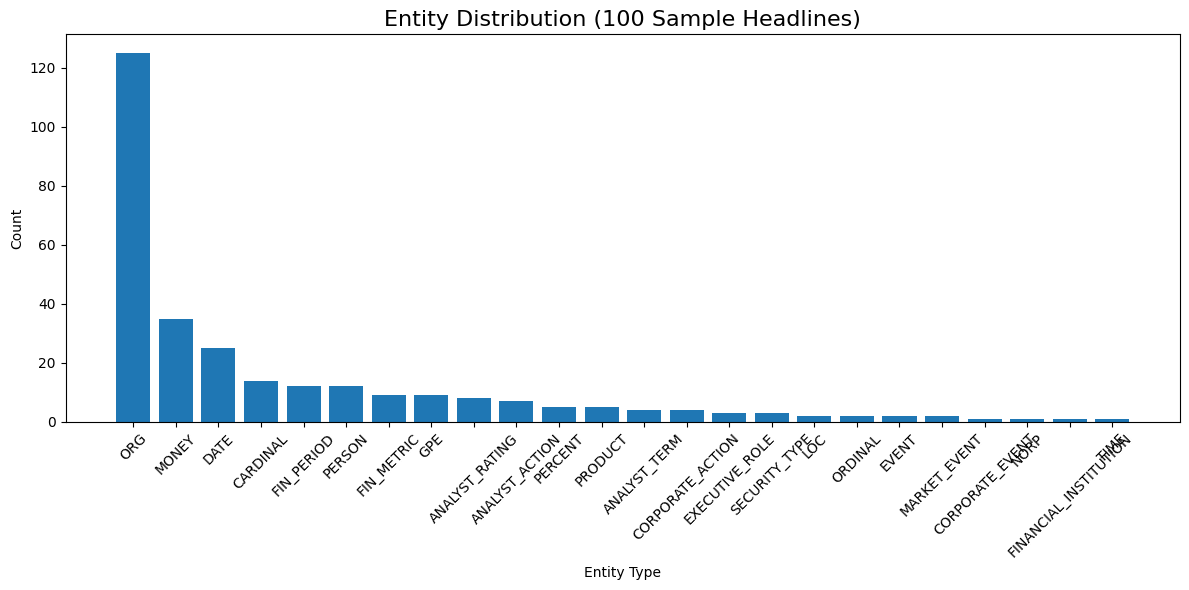

In [44]:
plt.figure(figsize=(12,6))

plt.bar(
    entity_stats["Entity Type"],
    entity_stats["Count"]
)

plt.title("Entity Distribution (100 Sample Headlines)", fontsize=16)

plt.xlabel("Entity Type")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 18. Save Sample Outputs

In [45]:
sample_df.to_parquet(
    os.path.join(
        INTERIM_DATA,
        "sample_news_entities.parquet"
    ),
    index=False
)

entity_table.to_parquet(
    os.path.join(
        INTERIM_DATA,
        "sample_entity_table.parquet"
    ),
    index=False
)

## 19.Summary

In [46]:
summary = pd.DataFrame({

    "Metric": [

        "Sample Headlines",

        "Total Extracted Entities",

        "Unique Entity Types",

        "Unique Companies",

        "Average Entities per Headline"

    ],

    "Value": [

        len(sample_df),

        len(entity_table),

        entity_table["entity_type"].nunique(),

        entity_table[
            entity_table["entity_type"] == "ORG"
        ]["normalized_entity"].nunique(),

        round(
            sample_df["entity_count"].mean(),
            2
        )

    ]

})

summary

,Metric,Value
0,Sample Headlines,100.00
1,Total Extracted Entities,292.00
2,Unique Entity Types,24.00
3,Unique Companies,115.00
4,Average Entities per Headline,2.92
